# Proyecto: Análisis de Test A/B en Tienda Online


## Introducción

En este proyecto se analiza el resultado de un test A/B realizado en una tienda online con el objetivo de evaluar diferentes hipótesis para aumentar los ingresos.

El análisis se divide en dos partes:
1. Priorización de hipótesis (ICE y RICE)
2. Análisis del test A/B mediante métricas clave y pruebas estadísticas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [10]:
hypotheses = pd.read_csv('/datasets/hypotheses_us.csv', sep=';')
orders = pd.read_csv('/datasets/orders_us.csv')
visits = pd.read_csv('/datasets/visits_us.csv')

**Exploración inicial y preprocesamiento
Revisar estructura de los datos**

In [11]:
print(hypotheses.info())
print()
print(orders.info())
print()
print(visits.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Effort      9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   transactionId  1197 non-null   int64  
 1   visitorId      1197 non-null   int64  
 2   date           1197 non-null   object 
 3   revenue        1197 non-null   float64
 4   group          1197 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 46.9+ KB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data c

In [4]:
print(hypotheses.head())
print()
print(orders.head())
print()
print(visits.head())

           Hypothesis;Reach;Impact;Confidence;Effort
0  Add two new channels for attracting traffic. T...
1  Launch your own delivery service. This will sh...
2  Add product recommendation blocks to the store...
3  Change the category structure. This will incre...
4  Change the background color on the main page. ...

   transactionId   visitorId        date  revenue group
0     3667963787  3312258926  2019-08-15     30.4     B
1     2804400009  3642806036  2019-08-15     15.2     B
2     2961555356  4069496402  2019-08-15     10.2     A
3     3797467345  1196621759  2019-08-15    155.1     B
4     2282983706  2322279887  2019-08-15     40.5     B

         date group  visits
0  2019-08-01     A     719
1  2019-08-02     A     619
2  2019-08-03     A     507
3  2019-08-04     A     717
4  2019-08-05     A     756


## Parte 1: Priorización de hipótesis

In [12]:
orders['date'] = pd.to_datetime(orders['date'])
visits['date'] = pd.to_datetime(visits['date'])

In [13]:
print('Duplicados en hypotheses:', hypotheses.duplicated().sum())
print('Duplicados en orders:', orders.duplicated().sum())
print('Duplicados en visits:', visits.duplicated().sum())

Duplicados en hypotheses: 0
Duplicados en orders: 0
Duplicados en visits: 0


In [14]:
print(hypotheses.isna().sum())
print()
print(orders.isna().sum())
print()
print(visits.isna().sum())

Hypothesis    0
Reach         0
Impact        0
Confidence    0
Effort        0
dtype: int64

transactionId    0
visitorId        0
date             0
revenue          0
group            0
dtype: int64

date      0
group     0
visits    0
dtype: int64


### Aplicación del framework ICE

In [15]:
hypotheses['ICE'] = (hypotheses['Impact'] * hypotheses['Confidence']) / hypotheses['Effort']
hypotheses[['Hypothesis', 'ICE']].sort_values(by='ICE', ascending=False)

,Hypothesis,ICE
8,Launch a promotion that gives users discounts ...,16.200000
0,Add two new channels for attracting traffic. T...,13.333333
7,Add a subscription form to all the main pages....,11.200000
6,Show banners with current offers and sales on ...,8.000000
2,Add product recommendation blocks to the store...,7.000000
1,Launch your own delivery service. This will sh...,2.000000
5,Add a customer review page. This will increase...,1.333333
3,Change the category structure. This will incre...,1.125000
4,Change the background color on the main page. ...,1.000000


**Conclusión:**
Al aplicar el framework ICE, la hipótesis con mayor prioridad es “Launch a promotion that gives users discounts on their birthdays”, con un puntaje de 16.2.
En segundo lugar queda “Add two new channels for attracting traffic”, con 13.33, y en tercero “Add a subscription form to all the main pages”, con 11.2.

Esto indica que, según ICE, las hipótesis más prometedoras son aquellas que combinan alto impacto, buena confianza y menor esfuerzo relativo. En cambio, hipótesis como cambiar el color de fondo de la página principal o modificar la estructura de categorías obtienen menor prioridad porque su impacto esperado no compensa el esfuerzo o la baja confianza.

### Aplicación del framework RICE

In [16]:
hypotheses['RICE'] = (hypotheses['Reach'] * hypotheses['Impact'] * hypotheses['Confidence']) / hypotheses['Effort']
hypotheses[['Hypothesis', 'RICE']].sort_values(by='RICE', ascending=False)

,Hypothesis,RICE
7,Add a subscription form to all the main pages....,112.0
2,Add product recommendation blocks to the store...,56.0
0,Add two new channels for attracting traffic. T...,40.0
6,Show banners with current offers and sales on ...,40.0
8,Launch a promotion that gives users discounts ...,16.2
3,Change the category structure. This will incre...,9.0
1,Launch your own delivery service. This will sh...,4.0
5,Add a customer review page. This will increase...,4.0
4,Change the background color on the main page. ...,3.0


### Comparación entre ICE y RICE

Al comparar los resultados de los frameworks ICE y RICE, se observa un cambio importante en la priorización de las hipótesis.

En el modelo ICE, la hipótesis mejor posicionada fue “Launch a promotion that gives users discounts…”, debido a su alto impacto y confianza con un esfuerzo relativamente bajo.

Sin embargo, al aplicar el modelo RICE, la hipótesis que ocupa el primer lugar es “Add a subscription form to all the main pages”, con un puntaje de 112.0, seguida por “Add product recommendation blocks” con 56.0.

Este cambio ocurre porque el modelo RICE incorpora el factor Reach (alcance), que mide cuántos usuarios se verán afectados por la hipótesis. En este caso, aunque la promoción tiene buen impacto, su alcance es menor en comparación con la implementación de un formulario de suscripción en todas las páginas, que potencialmente impacta a un mayor número de usuarios.

Por lo tanto, RICE proporciona una priorización más completa, ya que considera no solo la calidad de la hipótesis (impacto, confianza y esfuerzo), sino también su escala de impacto en la base de usuarios.

# Parte 2. Análisis del test A/B

### Preparación y limpieza de datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [7]:
orders = pd.read_csv('/datasets/orders_us.csv')
visits = pd.read_csv('/datasets/visits_us.csv')

In [18]:
orders.columns = orders.columns.str.strip().str.lower()
visits.columns = visits.columns.str.strip().str.lower()

In [9]:
users_in_both_groups = (
    orders.groupby('visitorid')['group']
    .nunique()
    .reset_index()
)

users_in_both_groups = users_in_both_groups[users_in_both_groups['group'] > 1]['visitorid']

print(users_in_both_groups.nunique())

58


### Ingreso acumulado por grupo

In [10]:
orders_filtered = orders[~orders['visitorid'].isin(users_in_both_groups)]

In [20]:
# Crear datos acumulados por fecha y grupo
dates_groups = orders_filtered[['date', 'group']].drop_duplicates()

orders_aggregated = (
    dates_groups.apply(
        lambda x: orders_filtered[
            (orders_filtered['date'] <= x['date']) &
            (orders_filtered['group'] == x['group'])
        ].agg({
            'date': 'max',
            'group': 'max',
            'transactionid': 'nunique',
            'visitorid': 'nunique',
            'revenue': 'sum'
        }),
        axis=1
    )
    .sort_values(by=['date', 'group'])
)

visits_aggregated = (
    dates_groups.apply(
        lambda x: visits[
            (visits['date'] <= x['date']) &
            (visits['group'] == x['group'])
        ].agg({
            'date': 'max',
            'group': 'max',
            'visits': 'sum'
        }),
        axis=1
    )
    .sort_values(by=['date', 'group'])
)

cumulative_data = orders_aggregated.merge(
    visits_aggregated, on=['date', 'group']
)

cumulative_data.columns = [
    'date', 'group', 'orders', 'buyers', 'revenue', 'visits'
]

In [21]:
cumulative_data.head()

,date,group,orders,buyers,revenue,visits
0,2019-08-01,A,23,19,2266.6,719
1,2019-08-01,B,17,17,967.2,713
2,2019-08-02,A,42,36,3734.9,1338
3,2019-08-02,B,40,39,3535.3,1294
4,2019-08-03,A,66,60,5550.1,1845


In [22]:
cumulative_a = cumulative_data[cumulative_data['group'] == 'A']
cumulative_b = cumulative_data[cumulative_data['group'] == 'B']

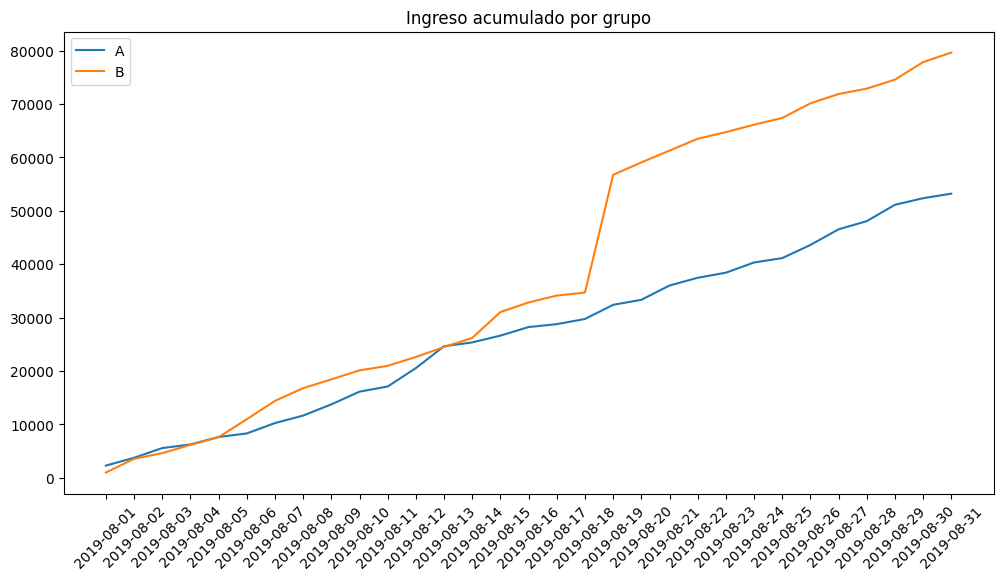

In [23]:

plt.figure(figsize=(12,6))

plt.plot(cumulative_a['date'], cumulative_a['revenue'], label='A')
plt.plot(cumulative_b['date'], cumulative_b['revenue'], label='B')

plt.title('Ingreso acumulado por grupo')
plt.legend()
plt.xticks(rotation=45)

plt.show()

**Conclusión:**
El grupo B muestra un ingreso acumulado superior al del grupo A durante casi todo el periodo analizado. También se observa un incremento brusco en el ingreso del grupo B en un punto específico, lo que puede indicar la presencia de uno o varios pedidos atípicos de alto valor. Por ello, aunque el grupo B parece liderar en ingresos, es necesario continuar el análisis con otras métricas y revisar la influencia de anomalías antes de tomar una decisión final.

### Tamaño de pedido promedio acumulado

In [35]:

cumulative_a = cumulative_data[cumulative_data['group'] == 'A'].copy()
cumulative_b = cumulative_data[cumulative_data['group'] == 'B'].copy()

cumulative_a['avg_order_value'] = cumulative_a['revenue'] / cumulative_a['orders']
cumulative_b['avg_order_value'] = cumulative_b['revenue'] / cumulative_b['orders']

In [36]:
merged_cumulative_avg = cumulative_a[['date', 'avg_order_value']].merge(
    cumulative_b[['date', 'avg_order_value']],
    on='date',
    suffixes=['A', 'B']
)

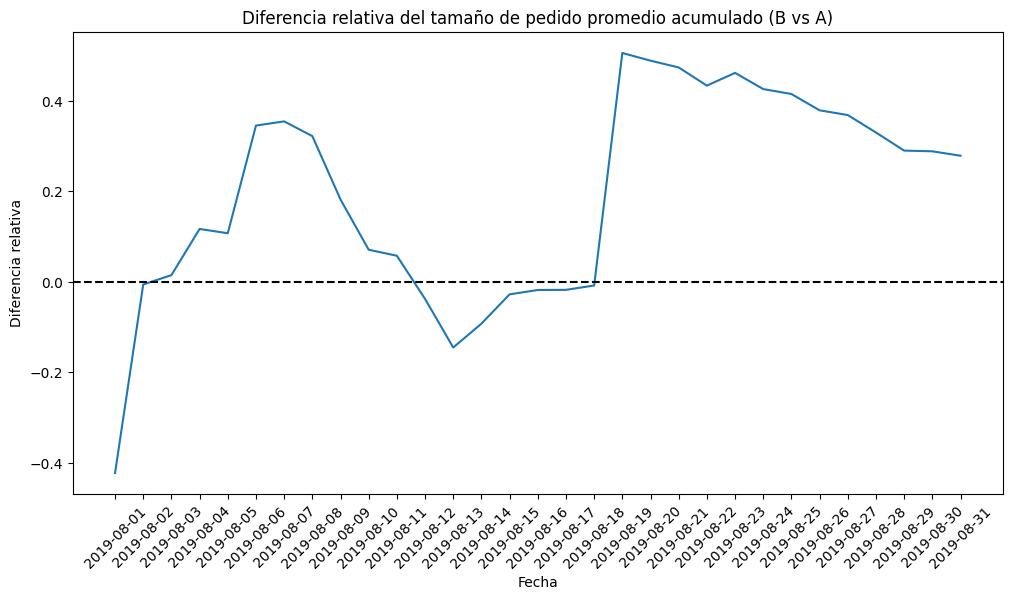

In [37]:
merged_cumulative_avg['relative_diff'] = (
    merged_cumulative_avg['avg_order_valueB'] /
    merged_cumulative_avg['avg_order_valueA']
) - 1

plt.figure(figsize=(12,6))

plt.plot(
    merged_cumulative_avg['date'],
    merged_cumulative_avg['relative_diff']
)

plt.axhline(y=0, color='black', linestyle='--')
plt.title('Diferencia relativa del tamaño de pedido promedio acumulado (B vs A)')
plt.xlabel('Fecha')
plt.ylabel('Diferencia relativa')
plt.xticks(rotation=45)

plt.show()

**Conclusión:**
La diferencia relativa del tamaño de pedido promedio acumulado entre los grupos A y B muestra variaciones considerables a lo largo del periodo analizado. En algunos momentos, el grupo B supera claramente al grupo A; sin embargo, la curva presenta oscilaciones fuertes y no se estabiliza de forma clara.

Esto sugiere que la métrica está influida por valores atípicos, probablemente pedidos de alto importe. Por ello, aunque el grupo B parece mostrar un mejor desempeño en ciertos periodos, no es posible concluir todavía que exista una mejora sostenida en el tamaño promedio de pedido sin antes analizar las anomalías.

### Tasa de conversión acumulada

In [38]:
cumulative_data['conversion'] = cumulative_data['orders'] / cumulative_data['visits']

In [39]:
cumulative_a = cumulative_data[cumulative_data['group'] == 'A']
cumulative_b = cumulative_data[cumulative_data['group'] == 'B']

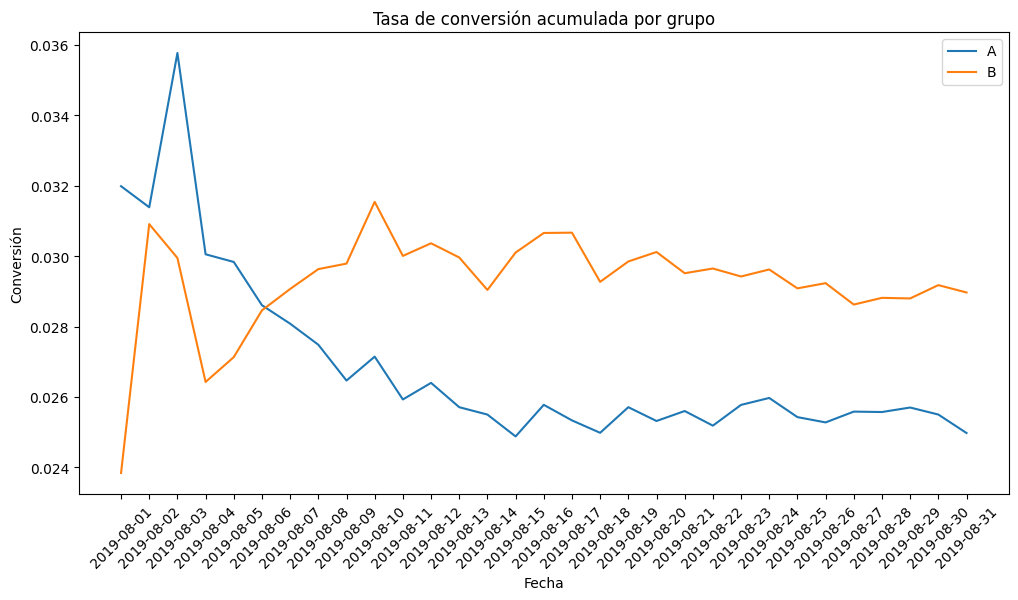

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(cumulative_a['date'], cumulative_a['conversion'], label='A')
plt.plot(cumulative_b['date'], cumulative_b['conversion'], label='B')

plt.title('Tasa de conversión acumulada por grupo')
plt.xlabel('Fecha')
plt.ylabel('Conversión')
plt.legend()
plt.xticks(rotation=45)

plt.show()

**Conclusión:**
La tasa de conversión acumulada del grupo B se mantiene por encima de la del grupo A durante la mayor parte del periodo analizado. Después de una fase inicial de variabilidad, la diferencia entre ambos grupos tiende a estabilizarse, lo que sugiere que el grupo B logra convertir una mayor proporción de visitantes en compradores de forma consistente.

Este comportamiento indica que la variante B podría estar generando una mejora real en la conversión, a diferencia de lo observado en el tamaño promedio de pedido, donde las diferencias parecen estar influenciadas por valores atípicos.

### Diferencia relativa de conversión (B vs A)

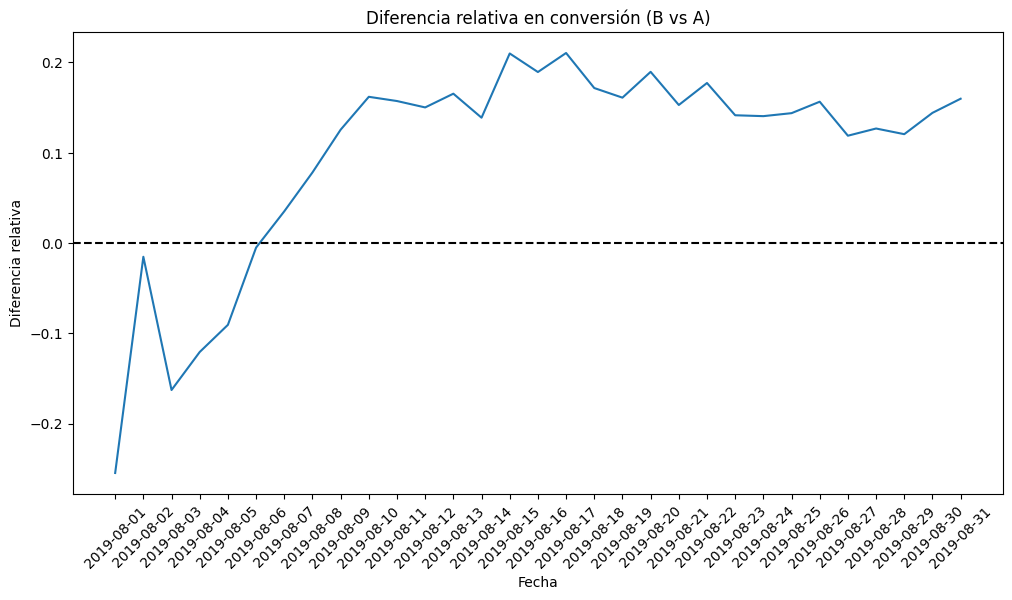

In [41]:
merged_conversions = cumulative_a[['date', 'conversion']].merge(
    cumulative_b[['date', 'conversion']],
    on='date',
    suffixes=['A', 'B']
)

plt.figure(figsize=(12,6))

plt.plot(
    merged_conversions['date'],
    (merged_conversions['conversionB'] / merged_conversions['conversionA']) - 1
)

plt.axhline(y=0, color='black', linestyle='--')

plt.title('Diferencia relativa en conversión (B vs A)')
plt.xlabel('Fecha')
plt.ylabel('Diferencia relativa')
plt.xticks(rotation=45)

plt.show()

**Conclusión:**
La diferencia relativa en la tasa de conversión muestra que el grupo B supera al grupo A durante gran parte del experimento. Después de las fluctuaciones iniciales, la diferencia tiende a estabilizarse por encima de cero, lo que indica que el grupo B tiene una conversión consistentemente mayor.

Esto refuerza la hipótesis de que la variante B mejora el desempeño en términos de conversión.

**Dispersión del número de pedidos por usuario**

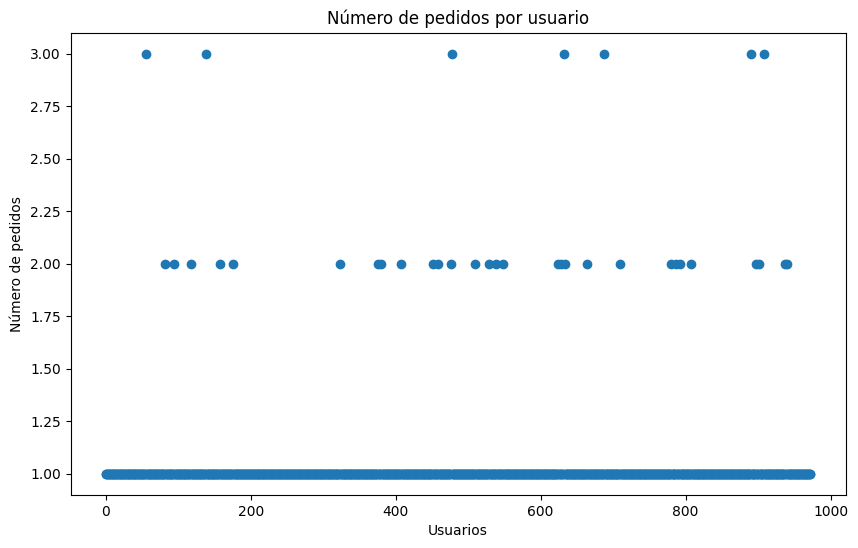

In [42]:
orders_by_users = (
    orders_filtered.groupby('visitorid', as_index=False)
    .agg({'transactionid': 'nunique'})
)

orders_by_users.columns = ['visitorid', 'orders']

x_values = pd.Series(range(0, len(orders_by_users)))

plt.figure(figsize=(10,6))

plt.scatter(x_values, orders_by_users['orders'])

plt.title('Número de pedidos por usuario')
plt.xlabel('Usuarios')
plt.ylabel('Número de pedidos')

plt.show()

**Conclusión:**
La mayoría de los usuarios realiza uno o dos pedidos, lo cual es consistente con el comportamiento esperado en una tienda online. Sin embargo, se observan algunos usuarios con un número significativamente mayor de pedidos, lo que indica la presencia de valores atípicos que podrían afectar el análisis de métricas agregadas

**Percentiles del número de pedidos por usuario**

In [45]:
np.percentile(orders_by_users['orders'], [95, 99])

array([1., 2.])

**Conclusión:**
El 95% de los usuarios realiza hasta 1 pedido, mientras que el 99% realiza hasta 2 pedidos. Esto indica que la gran mayoría de los usuarios realiza muy pocas compras. Por lo tanto, se puede considerar como anomalía a aquellos usuarios que realizan más de 1 pedido, ya que representan un comportamiento poco común dentro del conjunto de datos.

In [47]:
np.percentile(orders_filtered['revenue'], [95, 99])

array([414.275, 830.3  ])

**Conclusión:**
El 95% de los pedidos tiene un valor inferior a aproximadamente 414.28, mientras que el 99% se encuentra por debajo de aproximadamente 830.3. Esto indica que la mayoría de las transacciones se concentra en rangos de ingresos moderados. Por lo tanto, se puede considerar como anomalía a aquellos pedidos con un valor superior a 414.28, ya que representan valores atípicos que pueden distorsionar el análisis del tamaño promedio de pedido.

### Diferencia en conversión (datos sin filtrar)

In [48]:
import scipy.stats as stats

orders_per_user_a = orders_filtered[orders_filtered['group']=='A'].groupby('visitorid')['transactionid'].nunique()
orders_per_user_b = orders_filtered[orders_filtered['group']=='B'].groupby('visitorid')['transactionid'].nunique()

visits_per_group_a = visits[visits['group']=='A']['visits'].sum()
visits_per_group_b = visits[visits['group']=='B']['visits'].sum()

sample_a = pd.concat([orders_per_user_a, pd.Series(0, index=np.arange(visits_per_group_a - len(orders_per_user_a)))])
sample_b = pd.concat([orders_per_user_b, pd.Series(0, index=np.arange(visits_per_group_b - len(orders_per_user_b)))])

print("p-value:", stats.mannwhitneyu(sample_a, sample_b)[1])
print("diferencia relativa:", sample_b.mean() / sample_a.mean() - 1)

p-value: 0.011018084110014696
diferencia relativa: 0.1597977924896936


**Conclusión:**
El valor p obtenido es de 0.011, el cual es menor al nivel de significancia de 0.05. Esto indica que existe una diferencia estadísticamente significativa en la tasa de conversión entre los grupos A y B.

Además, la diferencia relativa es aproximadamente del 16%, lo que muestra que el grupo B tiene una conversión superior al grupo A. Por lo tanto, se puede concluir que la variante B mejora de manera significativa la tasa de conversión.

### Diferencia en tamaño de pedido (datos sin filtrar)

In [50]:
print(
    "p-value:",
    stats.mannwhitneyu(
        orders_filtered[orders_filtered['group']=='A']['revenue'],
        orders_filtered[orders_filtered['group']=='B']['revenue']
    )[1]
)

print(
    "diferencia relativa:",
    orders_filtered[orders_filtered['group']=='B']['revenue'].mean() /
    orders_filtered[orders_filtered['group']=='A']['revenue'].mean() - 1
)

p-value: 0.8622329690015668
diferencia relativa: 0.27834487693078414


**Conclusión:**
El valor p obtenido es de 0.862, el cual es mayor a 0.05. Esto indica que no existe una diferencia estadísticamente significativa en el tamaño promedio de pedido entre los grupos A y B.

Aunque la diferencia relativa muestra un incremento del 27% en el grupo B, este resultado no es confiable desde el punto de vista estadístico, ya que puede estar influenciado por valores atípicos. Por lo tanto, no se puede concluir que la variante B mejore el tamaño promedio de pedido.

## Conclusión final

Con base en el análisis realizado, se recomienda detener la prueba y considerar al grupo B como líder.

El grupo B presenta una mejora estadísticamente significativa en la tasa de conversión, con un incremento aproximado del 16% respecto al grupo A.

Por otro lado, no se encontró una diferencia significativa en el tamaño promedio de pedido, lo que sugiere que esta métrica no se ve afectada de forma consistente por la variante evaluada.

Dado que la conversión impacta directamente en el número de compras, se concluye que la variante B genera un beneficio real para el negocio.